In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install kaggle

In [7]:
import os

from google.colab import userdata
os.environ["KAGGLE_API_TOKEN"] = userdata.get('KAGGLE_API_TOKEN')

In [ ]:
!kaggle competitions download -c pixels-to-predictions
!unzip pixels-to-predictions.zip -d /content/data

In [ ]:
!pip install -q peft==0.18.1 bitsandbytes accelerate datasets pillow
!pip install transformers

In [ ]:
!pip install pandas

In [11]:
# ── 1. Imports & Configuration ───────────────────────────────────────────────
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── Paths ────────────────────────────────────────────────────────────────────
# Adjust these paths to match your local environment
DATA_DIR = Path("/content/data/images")
VAL_DATA_DIR = Path("/content/data")
# ── Model ────────────────────────────────────────────────────────────────────
MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

# ── Basic Settings ───────────────────────────────────────────────────────────
IMG_SIZE = 224
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cpu


In [12]:
# ── 2a. Load CSVs ─────────────────────────────────────────────────────────────
train_df = pd.read_csv("/content/data/train.csv")
val_df   = pd.read_csv("/content/data/val.csv")
test_df  = pd.read_csv("/content/data/test.csv")

# The 'choices' column is a JSON string, so we parse it
for df in [train_df, val_df, test_df]:
    df["choices"] = df["choices"].apply(json.loads)

TRAIN_SAMPLES_PER_EPOCH = 1000

In [13]:
# ── 2b-i. Imports for exploration ────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from collections import Counter

splits = {"train": train_df, "val": val_df, "test": test_df}

# ── Helper ────────────────────────────────────────────────────────────────────
def bar_plot(ax, counter, title, color, top_n=None):
    items = counter.most_common(top_n) if top_n else sorted(counter.items())
    labels, counts = zip(*items)
    bars = ax.barh(range(len(labels)), counts, color=color, alpha=0.85)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel("Count", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    max_c = max(counts)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_width() + max_c * 0.01, bar.get_y() + bar.get_height() / 2,
                str(count), va="center", fontsize=8)

# ── Summary table ─────────────────────────────────────────────────────────────
print("=" * 55)
print(f"{'Split':<10} {'Total':>7} {'Has image':>10} {'No image':>10}")
print("-" * 55)
for name, df in splits.items():
    has = df["image_path"].notna().sum()
    print(f"{name:<10} {len(df):>7,} {has:>10,} {len(df)-has:>10,}")
print("=" * 55)

Split        Total  Has image   No image
-------------------------------------------------------
train        3,109      3,109          0
val          1,048      1,048          0
test         1,008      1,008          0


In [14]:
# ── 2b-ii. Per-split text summary ─────────────────────────────────────────────
def print_split_distribution(df, name):
    print(f"\n{'─'*50}")
    print(f"  Split: {name}  (n={len(df):,})")
    print(f"{'─'*50}")

    subj_counter = Counter(df["subject"])
    print(f"\nTop 5 subjects ({name}):")
    for subj, cnt in subj_counter.most_common(5):
        print(f"  {subj:<35} {cnt:>5,}  ({cnt/len(df)*100:.1f}%)")

    print(f"\nGrade spread ({name}):")
    for grade, cnt in sorted(Counter(df["grade"].astype(str)).items()):
        print(f"  Grade {grade:<10} {cnt:>5,}  ({cnt/len(df)*100:.1f}%)")

    has_img = df["image_path"].notna().sum()
    print(f"\n  Has image: {has_img:,} ({has_img/len(df)*100:.1f}%)")
    print(f"  No image:  {len(df)-has_img:,} ({(len(df)-has_img)/len(df)*100:.1f}%)")

for name, df in splits.items():
    print_split_distribution(df, name)


──────────────────────────────────────────────────
  Split: train  (n=3,109)
──────────────────────────────────────────────────

Top 5 subjects (train):
  natural science                     2,264  (72.8%)
  social science                        768  (24.7%)
  language science                       77  (2.5%)

Grade spread (train):
  Grade grade1         5  (0.2%)
  Grade grade12       21  (0.7%)
  Grade grade2       115  (3.7%)
  Grade grade3       289  (9.3%)
  Grade grade4       484  (15.6%)
  Grade grade5       354  (11.4%)
  Grade grade6       611  (19.7%)
  Grade grade7       545  (17.5%)
  Grade grade8       685  (22.0%)

  Has image: 3,109 (100.0%)
  No image:  0 (0.0%)

──────────────────────────────────────────────────
  Split: val  (n=1,048)
──────────────────────────────────────────────────

Top 5 subjects (val):
  natural science                       777  (74.1%)
  social science                        243  (23.2%)
  language science                       28  (2.7%)

Gra

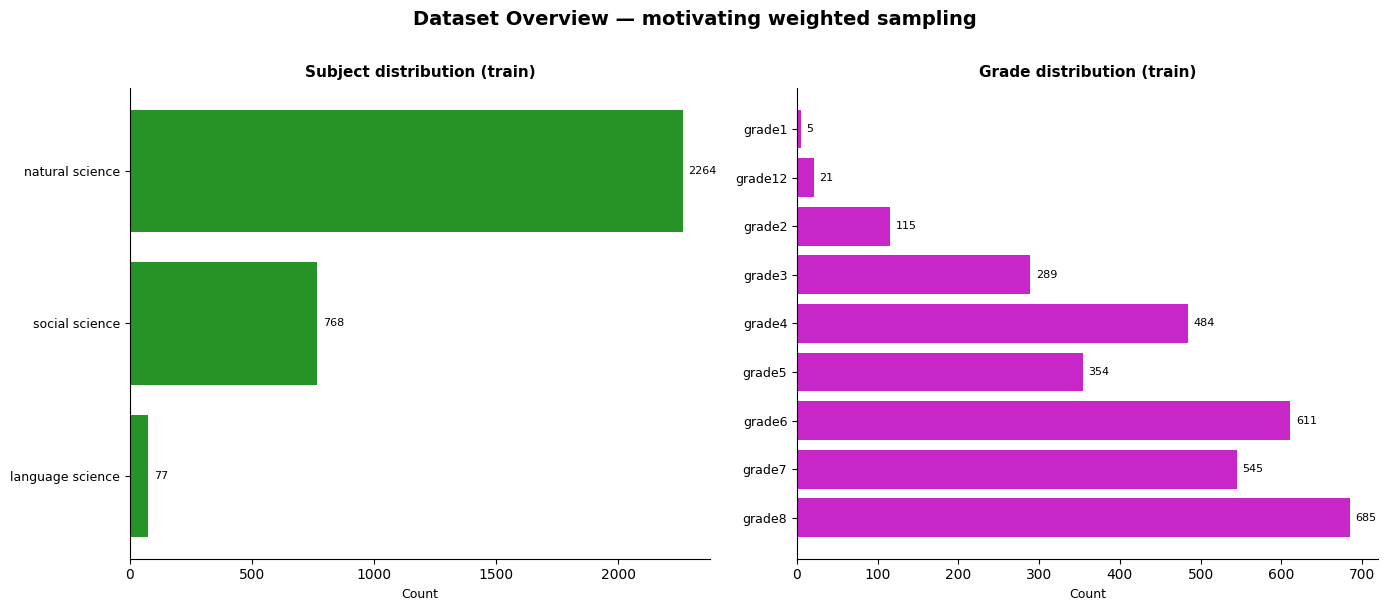

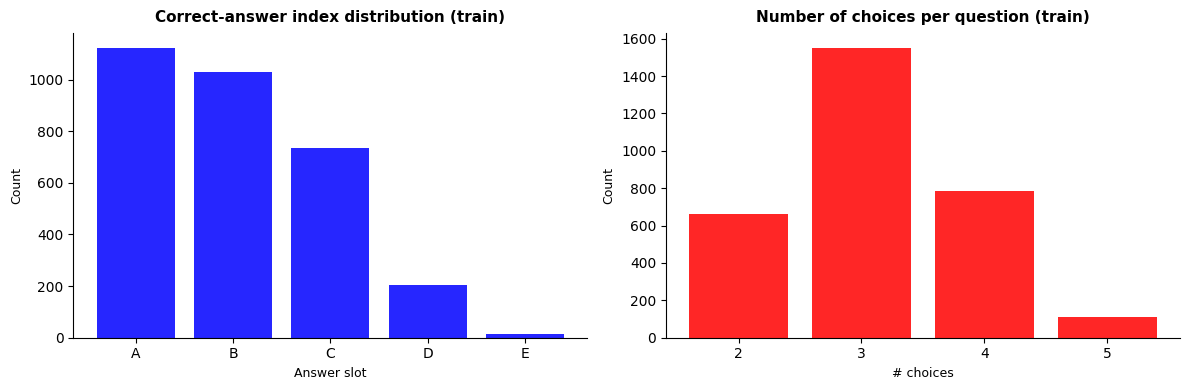

In [23]:
# ──Subject & Grade distribution plots ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subject distribution
bar_plot(axes[0], Counter(train_df["subject"]), "Subject distribution (train)", "g", top_n=15)

# Grade distribution
bar_plot(axes[1], Counter(train_df["grade"].astype(str)), "Grade distribution (train)", "m")

fig.suptitle("Dataset Overview — motivating weighted sampling",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# Answer index distribution (balance check) — train only
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4))

ans_counter = Counter(train_df["answer"].astype(int))
CHOICE_LETTERS = "ABCDEFGHIJ"
labeled = {CHOICE_LETTERS[k]: v for k, v in sorted(ans_counter.items())}
axes2[0].bar(labeled.keys(), labeled.values(), color="b", alpha=0.85)
axes2[0].set_title("Correct-answer index distribution (train)", fontsize=11, fontweight="bold", pad=8)
axes2[0].set_xlabel("Answer slot", fontsize=9)
axes2[0].set_ylabel("Count", fontsize=9)
axes2[0].spines[["top", "right"]].set_visible(False)

# Number of choices distribution
n_choices = train_df["choices"].apply(len)
choices_counter = Counter(n_choices)
axes2[1].bar([str(k) for k in sorted(choices_counter)],
             [choices_counter[k] for k in sorted(choices_counter)],
             color="r", alpha=0.85)
axes2[1].set_title("Number of choices per question (train)", fontsize=11, fontweight="bold", pad=8)
axes2[1].set_xlabel("# choices", fontsize=9)
axes2[1].set_ylabel("Count", fontsize=9)
axes2[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

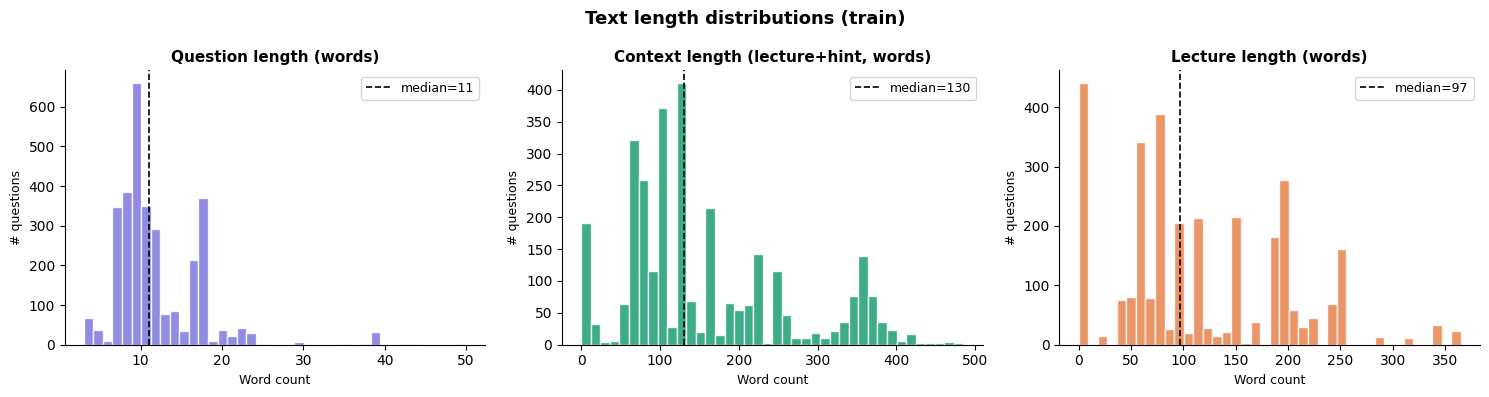


Question length (words):
count    3109.0
mean       11.9
std         5.4
min         3.0
25%         8.0
50%        11.0
75%        15.0
max        50.0

Context length (lecture + hint, words):
count    3109.0
mean      156.8
std       106.7
min         0.0
25%        75.0
50%       130.0
75%       222.0
max       485.0


In [ ]:
# Question & context length analysis
# Longer contexts matter for a 500M model with a limited context window
train_df["question_len"]  = train_df["question"].str.split().str.len()
train_df["lecture_len"]   = train_df["lecture"].fillna("").str.split().str.len()
train_df["hint_len"]      = train_df["hint"].fillna("").str.split().str.len()
train_df["context_len"]   = train_df["lecture_len"] + train_df["hint_len"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color, label in [
    (axes[0], "question_len",  "#F50505", "Question length (words)"),
    (axes[1], "context_len",   "#2106F1", "Context length (lecture+hint, words)"),
    (axes[2], "lecture_len",   "#51C90B", "Lecture length (words)"),
]:
    ax.hist(train_df[col], bins=40, color=color, alpha=0.85, edgecolor="white")
    ax.axvline(train_df[col].median(), color="black", linestyle="--",
               linewidth=1.2, label=f"median={train_df[col].median():.0f}")
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xlabel("Word count", fontsize=9)
    ax.set_ylabel("# questions", fontsize=9)
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Text length distributions (train)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nQuestion length (words):")
print(train_df["question_len"].describe().round(1).to_string())
print("\nContext length (lecture + hint, words):")
print(train_df["context_len"].describe().round(1).to_string())

Total strata (subject × grade): 22

Most common strata (top 5):
  natural science__grade8                         573
  natural science__grade6                         520
  natural science__grade7                         423
  natural science__grade4                         319
  natural science__grade5                         203

Rarest strata (bottom 5):
  language science__grade5                          7
  language science__grade1                          5
  language science__grade3                          3
  language science__grade6                          2
  language science__grade8                          1


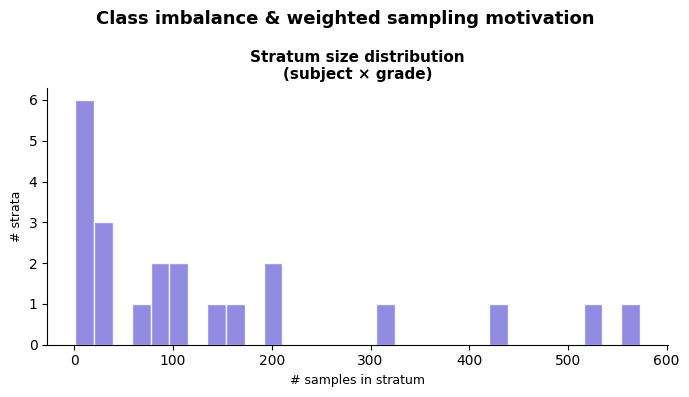

In [20]:
# Class imbalance analysis & sampling weights

# --- Stratum counts ---
train_df["stratum"] = train_df["subject"] + "__" + train_df["grade"].astype(str)
stratum_counts = train_df["stratum"].value_counts()

print(f"Total strata (subject × grade): {len(stratum_counts)}")
print(f"\nMost common strata (top 5):")
for s, c in stratum_counts.head(5).items():
    print(f"  {s:<45} {c:>5,}")
print(f"\nRarest strata (bottom 5):")
for s, c in stratum_counts.tail(5).items():
    print(f"  {s:<45} {c:>5,}")

# --- Inverse-frequency weights ---
inv_freq = 1.0 / stratum_counts
train_df["sample_weight"] = train_df["stratum"].map(inv_freq)
# Normalise so weights sum to len(train_df)
train_df["sample_weight"] = (
    train_df["sample_weight"] / train_df["sample_weight"].sum() * len(train_df)
)

# --- Stratum size distribution ---
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(stratum_counts.values, bins=30, color="#7F77DD", alpha=0.85, edgecolor="white")
ax.set_title("Stratum size distribution\n(subject × grade)", fontsize=11, fontweight="bold")
ax.set_xlabel("# samples in stratum", fontsize=9)
ax.set_ylabel("# strata", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Class imbalance & weighted sampling motivation",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()